# Import Library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
import os

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
torch.cuda.is_available()

True

# Import Data

In [3]:
train_df = pd.read_csv("train.csv", index_col=0)
valid_df = pd.read_csv("valid.csv", index_col=0)
test_df = pd.read_csv("test.csv", index_col=0)

train_df.head()

,original_path,id,label,label_str,path
0,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,31355,1,real,train/real/31355.jpg
1,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,02884,1,real,train/real/02884.jpg
2,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,33988,1,real,train/real/33988.jpg
3,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,53875,1,real,train/real/53875.jpg
4,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,24149,1,real,train/real/24149.jpg


# Exploratory Data Analysis (EDA)

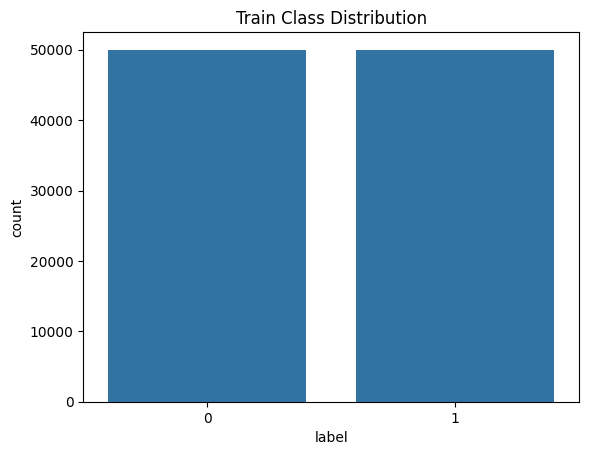

In [4]:
sns.countplot(data=train_df, x="label")
plt.title("Train Class Distribution")
plt.show()

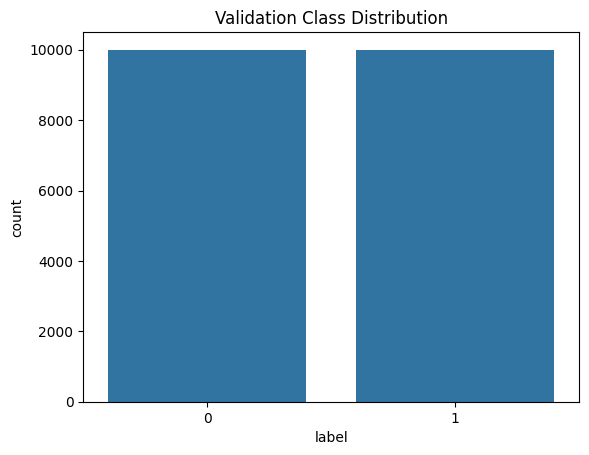

In [5]:
sns.countplot(data=valid_df, x="label")
plt.title("Validation Class Distribution")
plt.show()

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

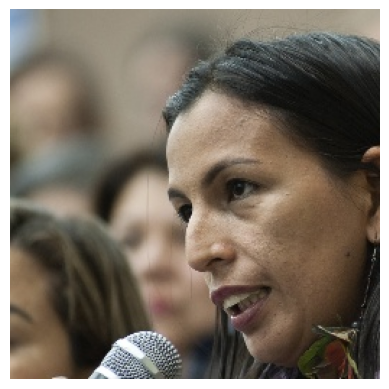

In [6]:
# Sample Checking
BASE_PATH = "real_vs_fake"

img_path = os.path.join(BASE_PATH, train_df.iloc[0]["path"])
img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")

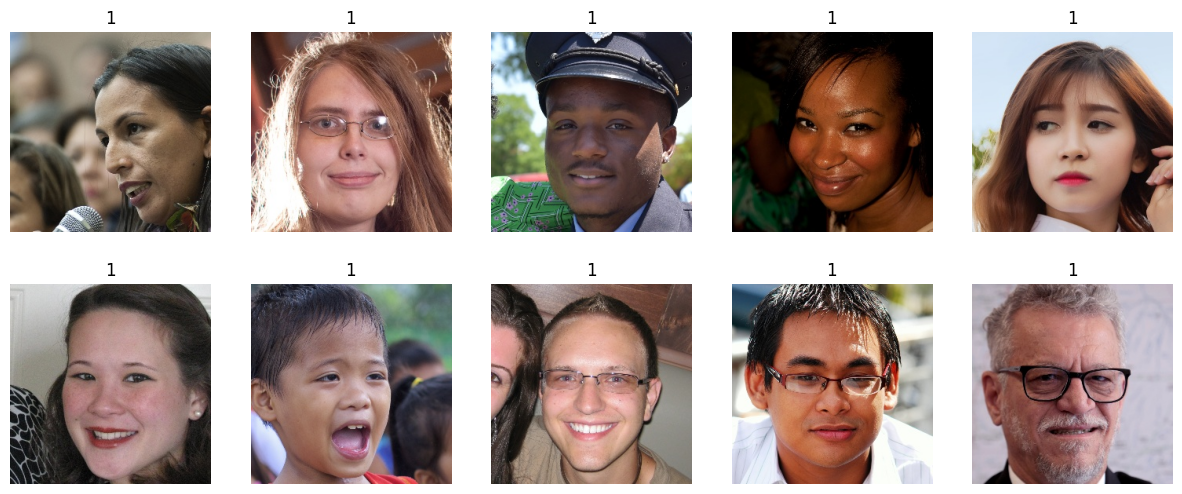

In [7]:
fig, axes = plt.subplots(2,5, figsize=(15,6))

for i, ax in enumerate(axes.flat):
    img_path = os.path.join(BASE_PATH,  train_df.iloc[i]["path"])
    img = Image.open(img_path)
    
    ax.imshow(img)
    ax.set_title(train_df.iloc[i]["label"])
    ax.axis("off")

In [8]:
# Check image size
sizes = []

for file in train_df["path"].sample(500):
    img = Image.open(os.path.join(BASE_PATH, file))
    sizes.append(img.size)

pd.Series(sizes).value_counts().head()

(256, 256)    500
Name: count, dtype: int64

Text(0.5, 1.0, 'Pixel Distribution')

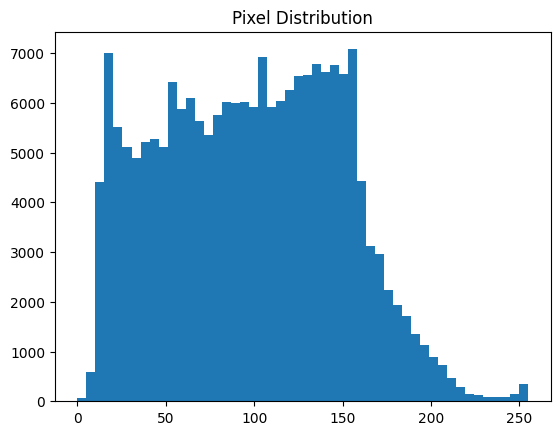

In [9]:
# Pixel Distribution
img = np.array(Image.open(os.path.join(BASE_PATH, train_df.iloc[0]["path"])))

plt.hist(img.flatten(), bins=50)
plt.title("Pixel Distribution")

In [ ]:
# Check for corrupted image
bad_images = []

for file in train_df["path"]:
    try:
        Image.open(os.path.join(BASE_PATH, file))
    except:
        bad_images.append(file)

print("Corrupted images:", len(bad_images))

Classes: ['fake', 'real']
Number of training images: 600000
Number of validation images: 20000
Number of test images: 20000


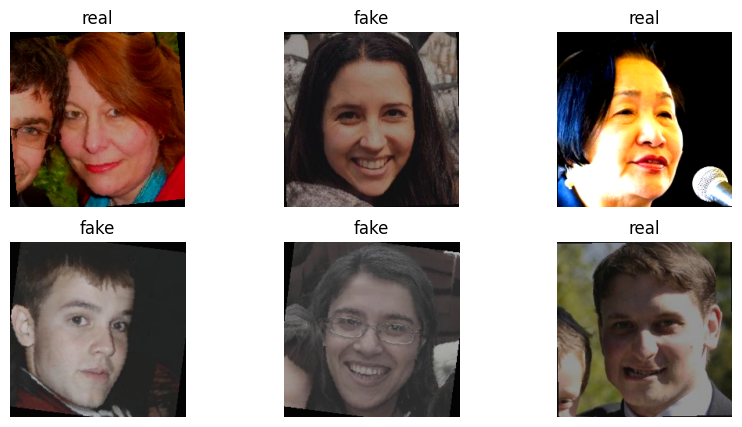

In [10]:
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406], 
    std=[0.229, 0.224, 0.225]
)

# Training: resize, augmentation, normalization
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    normalize
])

# Validation & Test: resize + normalization only
val_test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    normalize
])


train_dataset = datasets.ImageFolder(
    root="real_vs_fake/train",
    transform=train_transform
)

valid_dataset = datasets.ImageFolder(
    root="real_vs_fake/valid",
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    root="real_vs_fake/test",
    transform=val_test_transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Classes:", train_dataset.classes)
print("Number of training images:", len(train_dataset))
print("Number of validation images:", len(valid_dataset))
print("Number of test images:", len(test_dataset))

images, labels = next(iter(train_loader))
plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    img = images[i] * torch.tensor([0.229,0.224,0.225]).view(3,1,1) + torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    img = img.clamp(0,1) 
    plt.imshow(img.permute(1,2,0))
    plt.title(train_dataset.classes[labels[i]])
    plt.axis("off")
plt.show()

# Model Training (ResNet-18)

In [11]:
import torch
import torch.nn as nn
from torchvision import models
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [12]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [13]:
def train(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

In [14]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

In [16]:
best_valid_acc = 0
best_valid_round = 0

start_time = time.time()

for epoch in range(15):
    print(f"Epoch {epoch+1}")
    
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    valid_loss, valid_acc = evaluate(model, valid_loader, criterion, device)

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Validation Loss: {valid_loss:.4f}, Val Acc: {valid_acc:.4f}")

    torch.save(model.state_dict(), f"resnet18_epoch_{epoch+1}.pth")

    if valid_acc > best_valid_acc: 
        best_valid_acc = valid_acc
        best_valid_round = epoch + 1

    print(f"epoch time: {time.time() - start_time}")
        
print("Best epoch: ", best_valid_round)
print("Best validation", best_valid_acc)
print("Total time: ", time.time() - start_time)

Epoch 1
Train Loss: 0.0297, Train Acc: 0.9893
Validation Loss: 0.0176, Val Acc: 0.9939
epoch time: 3382.1053609848022
Epoch 2
Train Loss: 0.0204, Train Acc: 0.9926
Validation Loss: 0.0210, Val Acc: 0.9924
epoch time: 6747.992835283279
Epoch 3
Train Loss: 0.0158, Train Acc: 0.9943
Validation Loss: 0.0111, Val Acc: 0.9961
epoch time: 10140.156830310822
Epoch 4
Train Loss: 0.0127, Train Acc: 0.9955
Validation Loss: 0.0140, Val Acc: 0.9952
epoch time: 13500.631451368332
Epoch 5
Train Loss: 0.0113, Train Acc: 0.9960
Validation Loss: 0.0160, Val Acc: 0.9946
epoch time: 16870.88689994812
Epoch 6
Train Loss: 0.0095, Train Acc: 0.9966
Validation Loss: 0.0079, Val Acc: 0.9972
epoch time: 20261.238515138626
Epoch 7
Train Loss: 0.0086, Train Acc: 0.9970
Validation Loss: 0.0137, Val Acc: 0.9954
epoch time: 23643.355837106705
Epoch 8
Train Loss: 0.0079, Train Acc: 0.9972
Validation Loss: 0.0112, Val Acc: 0.9967
epoch time: 27025.774124145508
Epoch 9
Train Loss: 0.0070, Train Acc: 0.9976
Validation L

In [15]:
@torch.no_grad()
def test(model, loader, criterion, device):
    model.eval()
    
    y_true = []
    y_pred = []
    running_loss = 0.0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)

    return avg_loss, y_true, y_pred

In [18]:
model.load_state_dict(torch.load("resnet18_epoch_12.pth", map_location=device))

test_loss, y_true, y_pred = test(model, test_loader, criterion, device)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Loss     : {test_loss:.4f}")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

Loss     : 0.0098
Accuracy : 0.9975
Precision: 0.9968
Recall   : 0.9982
F1-score : 0.9975
